In [24]:
from PIL import Image
import numpy as np
import easyocr
import pytesseract
import cv2
from matplotlib import pyplot as plt
import os
import requests


In [25]:
reader = easyocr.Reader(['en'], gpu=False, verbose=False)
pytesseract.pytesseract.tesseract_cmd = r'C:\Program Files\Tesseract-OCR\tesseract.exe'

In [26]:
def unsharp_mask(image, kernel_size=(5, 5), sigma=1.0, amount=1.0, threshold=0):
    """Return a sharpened version of the image, using an unsharp mask."""
    blurred = cv2.GaussianBlur(image, kernel_size, sigma)
    sharpened = float(amount + 1) * image - float(amount) * blurred
    sharpened = np.maximum(sharpened, np.zeros(sharpened.shape))
    sharpened = np.minimum(sharpened, 255 * np.ones(sharpened.shape))
    sharpened = sharpened.round().astype(np.uint8)
    if threshold > 0:
        low_contrast_mask = np.absolute(image - blurred) < threshold
        np.copyto(sharpened, image, where=low_contrast_mask)
    return sharpened


In [ ]:
noOfFiles = len(os.listdir(f'cards\\'))

def ocr(image):
    numArr = []
    for i in range(0,3):
        length = 60
        if i == 0:
            x = 153
        elif i == 1:
            x = 427
        else:
            x = 701
        cropped = image[372:385, x:x+length]
        plt.imshow(cropped)
        plt.show()
        upscaled = cv2.resize(cropped, (0,0), fx = 8, fy = 8)
        gray = cv2.cvtColor(upscaled, cv2.COLOR_RGB2GRAY)
        _, thresholded = cv2.threshold(gray, 64, 255,
            cv2.THRESH_BINARY_INV)

        blurred = cv2.GaussianBlur(thresholded, (3, 3), 1)
        sharpened = unsharp_mask(blurred, kernel_size=(3,3))

        OcrImage = sharpened
        plt.imshow(OcrImage, cmap='gray')
        plt.show()
        results = reader.readtext(OcrImage, allowlist='0123456789. ', min_size = 5)
        numArr.append(int((results[0][1].lstrip().split(" ")[0].split(".")[0][:5])))
    return numArr


for j in range(1,noOfFiles+1):
    print(f'card{j}.webp')
    card_image = cv2.imread(f'cards\\card{j}.webp')
    card_num = ocr(card_image)
    print(card_num)




In [ ]:
url = r'https://cdn.discordapp.com/attachments/1316412274734399528/1347882128733638686/card.webp?ex=67cd708d&is=67cc1f0d&hm=18b332d62b95c7dca22e2141d8d9922fb5a5541015c002e602e419e41c76e9ba&'
resp = requests.get(url, stream=True).raw
image = np.asarray(bytearray(resp.read()), dtype="uint8")
image = cv2.imdecode(image, cv2.IMREAD_COLOR)
plt.imshow(image)
plt.show()
card_num = ocr(image)
print(card_num)

card1.webp


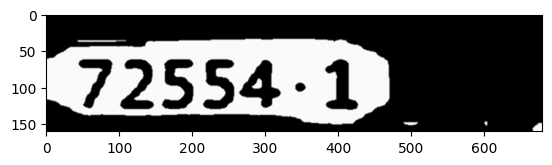

72554.1


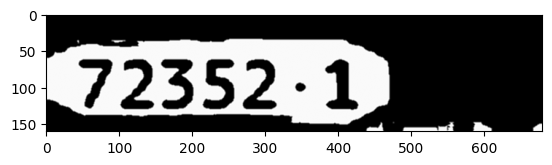

72352.1


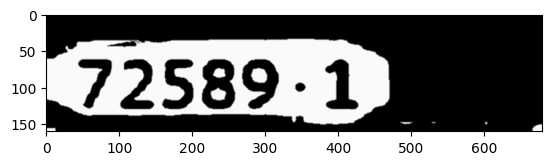

72589.1
[72554, 72352, 72589]
[1, 1, 1]
card2.webp


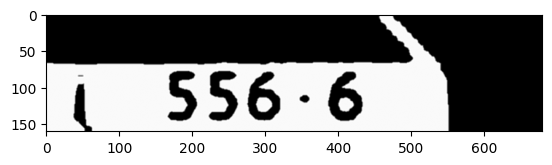

556.6


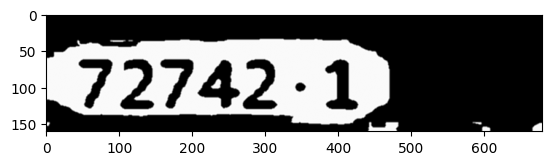

72742.1


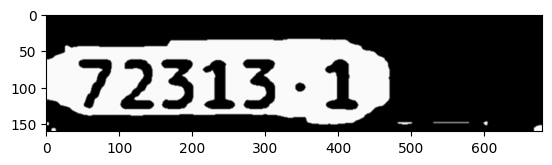

72313.1
[556, 72742, 72313]
[6, 1, 1]
card3.webp


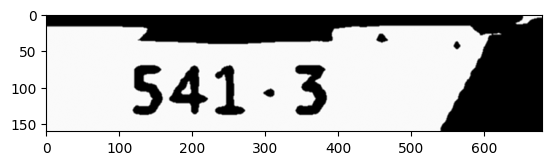

541.3


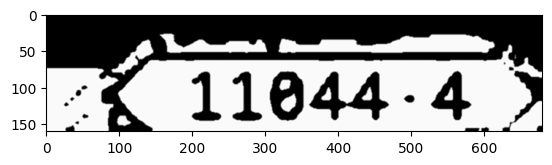

11044.4


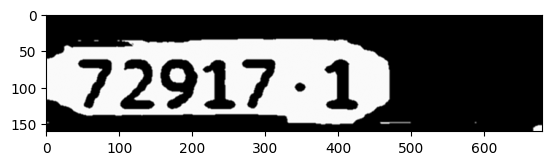

72917.1
[541, 11044, 72917]
[3, 4, 1]
card4.webp


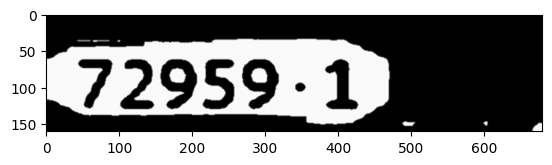

72959.1


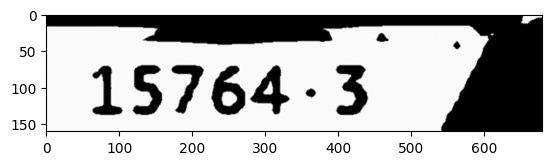

15764.3


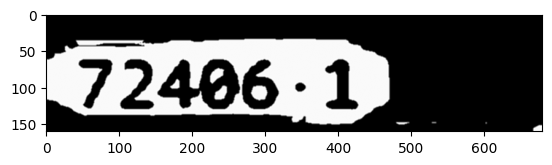

72406.1
[72959, 15764, 72406]
[1, 3, 1]
card5.webp


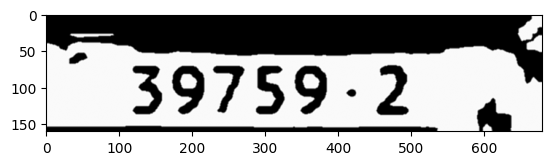

39759.2


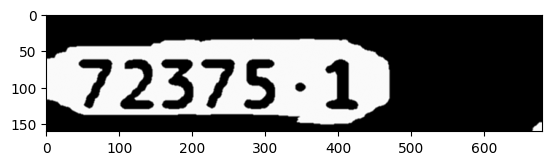

72375.1


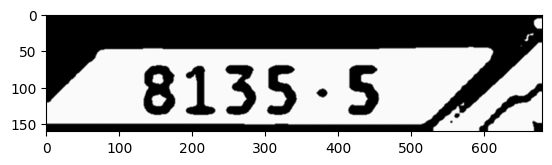

8135.5
[39759, 72375, 8135]
[2, 1, 5]
card6.webp


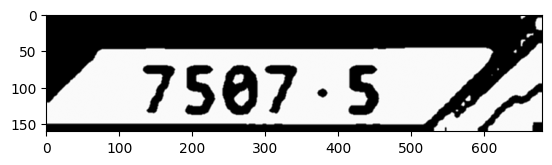

7507.5


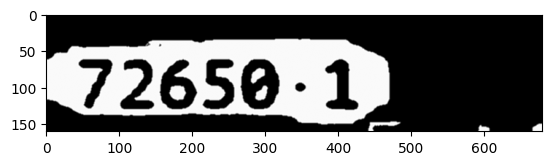

72650.1


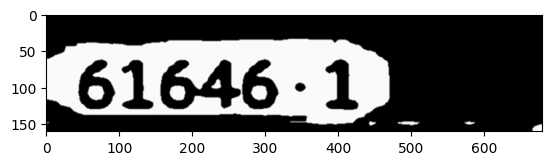

61646.1
[7507, 72650, 61646]
[5, 1, 1]
card7.webp


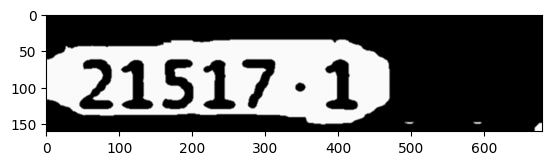

21517.1


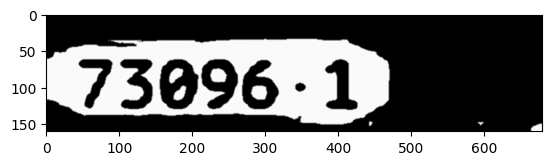

73096.1


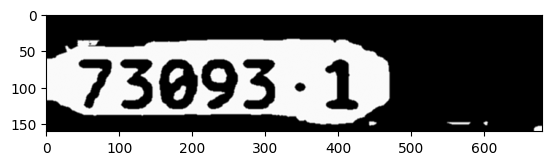

73093.1
[21517, 73096, 73093]
[1, 1, 1]
card8.webp


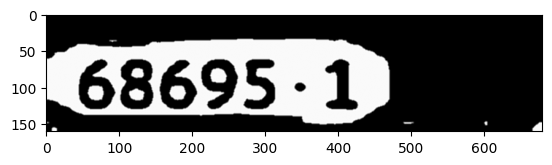

68695.1


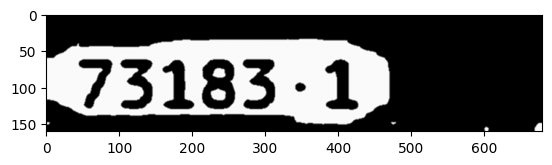

73183.1


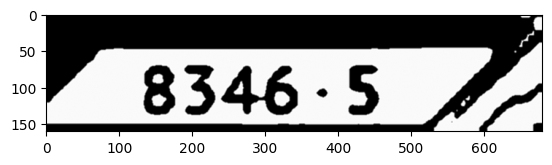

8346.5
[68695, 73183, 8346]
[1, 1, 5]
card9.webp


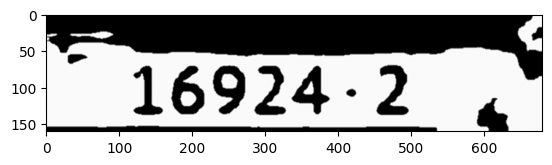

16924.2


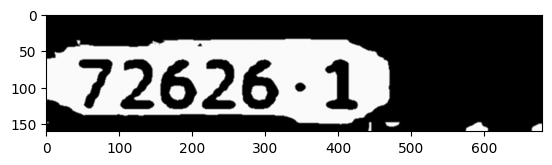

72626.1


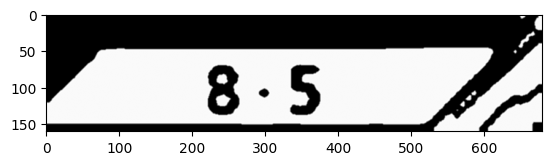

8.5
[16924, 72626, 8]
[2, 1, 5]
card10.webp


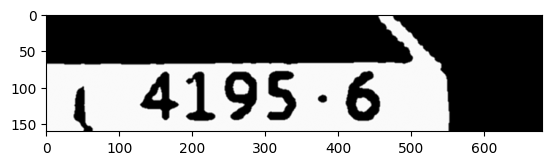

4195.6


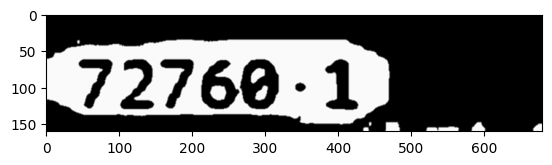

72760.1


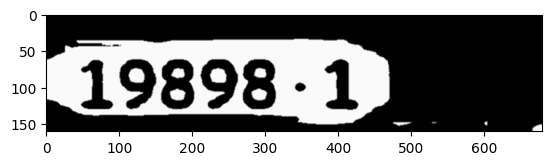

19898.1
[4195, 72760, 19898]
[6, 1, 1]
card11.webp


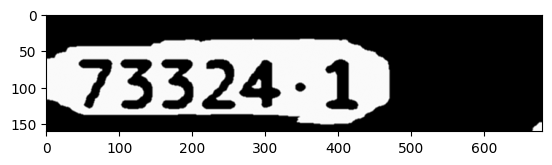

73324.1


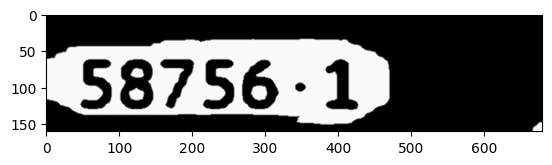

58756.1


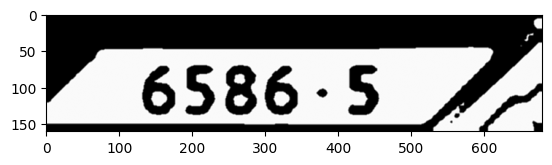

6586.5
[73324, 58756, 6586]
[1, 1, 5]
card12.webp


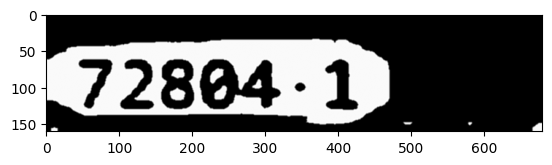

72804.1


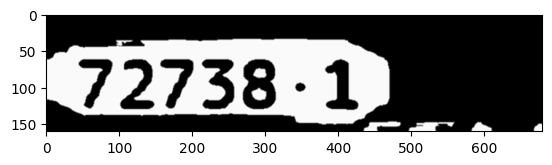

KeyboardInterrupt: 

In [ ]:
def ocr(image):
    printArr = []
    genArr = []
    for i in range(0,3):
        outputString = ""
        length = 85
        y = 365
        if i == 0:
            x = 155
        elif i == 1:
            x = 429
        else:
            x = 703
        cropped = image[y:y+20, x:x+length]
        upscaled = cv2.resize(cropped, (0,0), fx = 8, fy = 8)
        gray = cv2.cvtColor(upscaled, cv2.COLOR_RGB2GRAY)
        lowerThreshold = 64
        _, thresholded = cv2.threshold(gray, lowerThreshold, 250,
            cv2.THRESH_BINARY_INV)

        blurred = cv2.GaussianBlur(thresholded, (3, 3), 1)
        sharpened = unsharp_mask(blurred, kernel_size=(3,3))

        OcrImage = sharpened
        plt.imshow(OcrImage, cmap='gray')
        plt.show()
        results = reader.readtext(OcrImage, allowlist='0123456789. ', min_size = 5)
        totalConfidence = 0
        for result in results:
            outputString += "."
            outputString += result[1]
            totalConfidence += result[2]
        outputString = outputString.strip().strip('.').replace(" ", "").replace("..",".")
        print(outputString)
        try:
            printArr.append(int(outputString.split(".")[0]))
        except ValueError:
            print("ValueError")
            printArr.append(90000)
        except IndexError:
            print("IndexError")
            printArr.append(90000)
        try:
            genArr.append(int(outputString.split(".")[1]))
        except ValueError:
            genArr.append(1)
        except IndexError:
            genArr.append(1)
    return printArr, genArr


noOfFiles = len(os.listdir(f'cards\\'))
for j in range(1,noOfFiles+1):
    print(f'card{j}.webp')
    card_image = cv2.imread(f'cards\\card{j}.webp')
    printArr, genArr = ocr(card_image)
    print(printArr)
    print(genArr)

